# PowerBid — Turkish Day-Ahead Market Bidding Assistant

AI-powered bidding decision support system for the Turkish electricity day-ahead market (GÖP).

## Architecture
```
Layer 1 — Data      : EPİAŞ API (PTF, generation, consumption) + Open-Meteo (weather)
Layer 2 — Model     : Random Forest price forecasting
Layer 3 — Decision  : PTF forecast + confidence interval + bid recommendation
Output              : Daily bid report (24 hours)
```

## Sections
1. Setup & imports
2. Data collection (EPİAŞ + Open-Meteo)
3. Feature engineering
4. Model training
5. Decision engine
6. Daily bid report

## 1 — Setup & Imports

In [1]:
!pip install eptr2 -q
print('eptr2 installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 4.8 MB/s eta 0:00:00
eptr2 installed.


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from eptr2 import EPTR2
from google.colab import userdata
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# EPİAŞ credentials — set in Colab Secrets (key icon in left sidebar)
# Name: EPIAS_USERNAME, EPIAS_PASSWORD
username = userdata.get('EPIAS_USERNAME')
password = userdata.get('EPIAS_PASSWORD')
eptr = EPTR2(username=username, password=password)
print('EPİAŞ client ready.')

Dotenv file not found at .env.
EPİAŞ client ready.


---
## 2 — Data Collection

### 2a — PTF (Market Clearing Price)
PTF = Piyasa Takas Fiyatı. Hourly day-ahead price in TRY/MWh.

In [3]:
print('Fetching PTF data...')
result = eptr.call('mcp', start_date='2025-04-01', end_date='2026-04-01')

df_tr = result.copy()
df_tr['datetime'] = pd.to_datetime(df_tr['date']).dt.tz_localize(None)
df_tr['hour']     = df_tr['datetime'].dt.hour
df_tr['month']    = df_tr['datetime'].dt.month
df_tr = df_tr.dropna(subset=['price']).reset_index(drop=True)

print(f'PTF rows   : {len(df_tr)}')
print(f'Min price  : {df_tr["price"].min():.1f} TRY/MWh')
print(f'Max price  : {df_tr["price"].max():.1f} TRY/MWh')
print(f'Avg price  : {df_tr["price"].mean():.1f} TRY/MWh')

Fetching PTF data...
PTF rows   : 8784
Min price  : 0.0 TRY/MWh
Max price  : 3400.0 TRY/MWh
Avg price  : 2569.2 TRY/MWh


### 2b — Generation & Consumption
EPİAŞ limits these endpoints to 3-month windows — we loop quarterly.

In [4]:
PERIODS = [
    ('2025-04-01', '2025-06-30'),
    ('2025-07-01', '2025-09-30'),
    ('2025-10-01', '2025-12-31'),
    ('2026-01-01', '2026-04-01'),
]

def fetch_quarterly(call_name):
    dfs = []
    for s, e in PERIODS:
        try:
            df = eptr.call(call_name, start_date=s, end_date=e)
            dfs.append(df)
            print(f'  {s} -> {e}: {len(df)} rows')
            time.sleep(1)
        except Exception as ex:
            print(f'  {s} -> {e}: Error - {ex}')
    return pd.concat(dfs, ignore_index=True) if dfs else None

# Generation
print('Fetching generation...')
rt_gen = fetch_quarterly('rt-gen')
rt_gen['datetime']  = pd.to_datetime(rt_gen['date']).dt.tz_localize(None)
rt_gen['renewable'] = rt_gen['wind'] + rt_gen['sun'] + \
                      rt_gen['river'] + rt_gen['geothermal']
rt_gen = rt_gen.drop_duplicates(subset=['datetime']).reset_index(drop=True)
print(f'Generation rows: {len(rt_gen)}')

# Consumption — columns vary by API version, detect automatically
print('\nFetching consumption...')
rt_cons_raw = fetch_quarterly('rt-cons')
print(f'Raw columns: {rt_cons_raw.columns.tolist()}')

# Find datetime and numeric consumption column dynamically
rt_cons_raw['_dt'] = pd.to_datetime(rt_cons_raw['date']).dt.tz_localize(None)
numeric_cols = rt_cons_raw.select_dtypes(include='number').columns.tolist()
cons_col = numeric_cols[0] if numeric_cols else None

if cons_col is None:
    # Try to find float column by converting
    for col in rt_cons_raw.columns:
        if col not in ['date', '_dt']:
            converted = pd.to_numeric(rt_cons_raw[col], errors='coerce')
            if converted.notna().sum() > 1000:
                cons_col = col
                rt_cons_raw[col] = converted
                break

print(f'Consumption column: {cons_col}')
rt_cons = rt_cons_raw[['_dt', cons_col]].copy()
rt_cons.columns = ['datetime', 'consumption_mwh']
rt_cons['consumption_mwh'] = pd.to_numeric(rt_cons['consumption_mwh'], errors='coerce')
rt_cons = rt_cons.drop_duplicates(subset=['datetime']).reset_index(drop=True)
print(f'Consumption rows: {len(rt_cons)}')
print(rt_cons.head(3))

Fetching generation...
  2025-04-01 -> 2025-06-30: 2184 rows
  2025-07-01 -> 2025-09-30: 2208 rows
  2025-10-01 -> 2025-12-31: 2208 rows
  2026-01-01 -> 2026-04-01: 2184 rows
Generation rows: 8784

Fetching consumption...
  2025-04-01 -> 2025-06-30: 2184 rows
  2025-07-01 -> 2025-09-30: 2208 rows
  2025-10-01 -> 2025-12-31: 2208 rows
  2026-01-01 -> 2026-04-01: 2184 rows
Raw columns: ['date', 'time', 'consumption']
Consumption column: consumption
Consumption rows: 8784
             datetime  consumption_mwh
0 2025-04-01 00:00:00         27099.76
1 2025-04-01 01:00:00         25580.40
2 2025-04-01 02:00:00         24287.63


### 2c — Weather (Open-Meteo)
Free API, no registration. Location: Ankara as Turkish grid proxy.

In [5]:
WEATHER_PARAMS = ['temperature_2m','cloudcover','windspeed_10m','shortwave_radiation']

def get_weather_historical(lat=39.9, lon=32.8,
                            start='2025-04-01', end='2026-04-01'):
    url = 'https://archive-api.open-meteo.com/v1/archive'
    r   = requests.get(url, params={
        'latitude': lat, 'longitude': lon,
        'start_date': start, 'end_date': end,
        'hourly': WEATHER_PARAMS,
        'timezone': 'Europe/Istanbul'
    })
    df = pd.DataFrame(r.json()['hourly'])
    df['datetime'] = pd.to_datetime(df['time'])
    df['hour']     = df['datetime'].dt.hour
    df['month']    = df['datetime'].dt.month
    return df[['datetime','hour','month'] + WEATHER_PARAMS]

def get_weather_forecast(lat=39.9, lon=32.8, days=2):
    url = 'https://api.open-meteo.com/v1/forecast'
    r   = requests.get(url, params={
        'latitude': lat, 'longitude': lon,
        'hourly': WEATHER_PARAMS,
        'forecast_days': days,
        'timezone': 'Europe/Istanbul'
    })
    df = pd.DataFrame(r.json()['hourly'])
    df['datetime'] = pd.to_datetime(df['time'])
    df['hour']     = df['datetime'].dt.hour
    df['month']    = df['datetime'].dt.month
    return df[['datetime','hour','month'] + WEATHER_PARAMS]

print('Fetching historical weather...')
df_weather = get_weather_historical()
print(f'Weather rows: {len(df_weather)}')

Fetching historical weather...
Weather rows: 8784


---
## 3 — Feature Engineering

Key derived features:
- `net_surplus` = renewable − consumption
- `re_share` = renewable / total × 100
- `price_lag24` = same hour yesterday
- `price_lag168` = same hour last week

In [6]:
# Align datetime types
for dframe in [df_tr, df_weather, rt_gen, rt_cons]:
    dframe['datetime'] = pd.to_datetime(dframe['datetime']).dt.tz_localize(None)

# Merge
df = df_tr[['datetime','hour','month','price']]\
    .merge(df_weather[['datetime'] + WEATHER_PARAMS], on='datetime', how='inner')\
    .merge(rt_gen[['datetime','total','renewable','wind','sun']], on='datetime', how='inner')\
    .merge(rt_cons[['datetime','consumption_mwh']], on='datetime', how='inner')

# Numeric conversion
for col in ['renewable','consumption_mwh','total','wind','sun']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Derived features
df['net_surplus'] = df['renewable'] - df['consumption_mwh']
df['re_share']    = df['renewable'] / df['total'] * 100

# Lag + time features
df = df.sort_values('datetime').reset_index(drop=True)
df['price_lag24']  = df['price'].shift(24)
df['price_lag168'] = df['price'].shift(168)
df['dayofweek']    = df['datetime'].dt.dayofweek
df['is_weekend']   = (df['dayofweek'] >= 5).astype(int)
df = df.dropna().reset_index(drop=True)

print(f'Final dataset: {len(df)} hours')
print('\nCorrelations with PTF:')
for col in ['re_share','net_surplus','shortwave_radiation',
            'wind','temperature_2m','price_lag24']:
    print(f'  {col:25s}: {df[col].corr(df["price"]):+.3f}')

Final dataset: 8616 hours

Correlations with PTF:
  re_share                 : -0.687
  net_surplus              : -0.491
  shortwave_radiation      : -0.357
  wind                     : -0.139
  temperature_2m           : +0.046
  price_lag24              : +0.673


---
## 4 — Model Training (Random Forest)

**Target:** PTF (TRY/MWh)  
**Train/test split:** 80/20, no shuffle (time series)

PowerBid Model
MAE : 592.5 TRY/MWh
R2  : 0.481
Test: 1724 hours


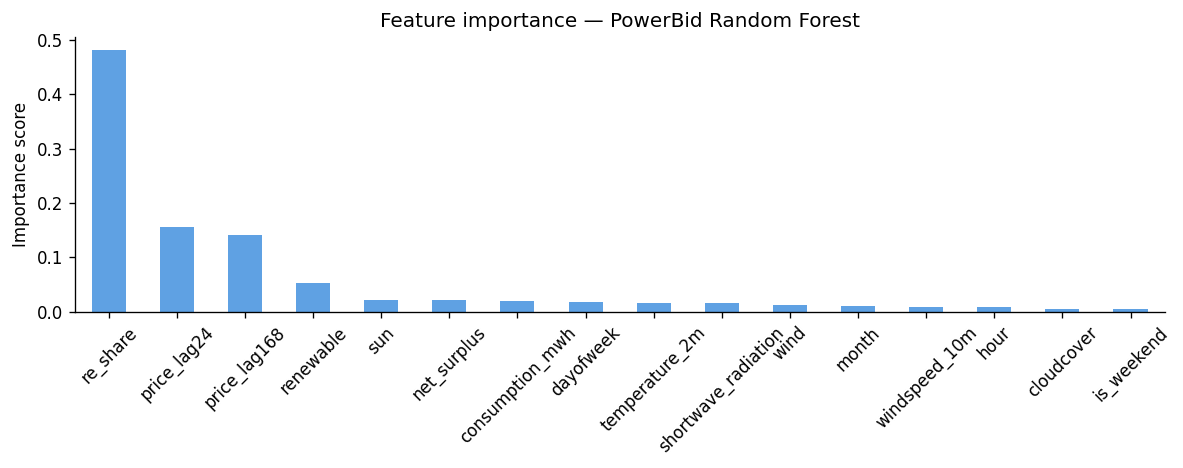

re_share               0.481
price_lag24            0.157
price_lag168           0.141
renewable              0.054
sun                    0.022
net_surplus            0.022
consumption_mwh        0.020
dayofweek              0.018
temperature_2m         0.017
shortwave_radiation    0.016
wind                   0.013
month                  0.012
windspeed_10m          0.009
hour                   0.009
cloudcover             0.006
is_weekend             0.005
dtype: float64


In [7]:
FEATURES = [
    'hour', 'month', 'dayofweek', 'is_weekend',
    'temperature_2m', 'cloudcover',
    'windspeed_10m',  'shortwave_radiation',
    'renewable',      'wind', 'sun',
    'consumption_mwh','net_surplus', 're_share',
    'price_lag24',    'price_lag168'
]

X = df[FEATURES]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

rf = RandomForestRegressor(
    n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'PowerBid Model')
print(f'MAE : {mae:.1f} TRY/MWh')
print(f'R2  : {r2:.3f}')
print(f'Test: {len(y_test)} hours')

# Feature importance chart
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
importances.plot(kind='bar', ax=ax, color='#378ADD', alpha=0.8)
ax.set_title('Feature importance — PowerBid Random Forest')
ax.set_ylabel('Importance score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(importances.round(3))

---
## 5 — Decision Engine

For each of the next 24 hours, PowerBid outputs:
- **PTF forecast** — Random Forest prediction
- **Confidence interval** — ±0.5 std of historical same-hour prices
- **Recommended bid** — conservative (85% of forecast, capped at historical Q25)
- **Acceptance probability** — % of historical hours where PTF ≥ bid
- **Risk label** — LOW (≥85%), MED (≥75%), HIGH (<75%)

In [8]:
# Tomorrow's weather forecast
df_forecast = get_weather_forecast(days=2)
tomorrow    = (pd.Timestamp.now() + pd.Timedelta(days=1)).date()
df_tomorrow = df_forecast[
    df_forecast['datetime'].dt.date == tomorrow
].copy().reset_index(drop=True)

print(f"Forecast for {tomorrow}: {len(df_tomorrow)} hours")
print(df_tomorrow[['hour','temperature_2m','cloudcover',
                   'shortwave_radiation']].to_string(index=False))

Forecast for 2026-04-09: 24 hours
 hour  temperature_2m  cloudcover  shortwave_radiation
    0             1.9           6                  0.0
    1             1.7           6                  0.0
    2             1.3           0                  0.0
    3             0.7           3                  0.0
    4             0.4           0                  0.0
    5             0.1           0                  0.0
    6            -0.2          12                  0.0
    7            -0.2          49                 18.0
    8             0.8          89                155.0
    9             2.2          93                330.0
   10             3.9         100                530.0
   11             5.6          94                686.0
   12             7.0         100                793.0
   13             8.2         100                836.0
   14             8.9          57                806.0
   15             9.0         100                656.0
   16             8.7         1

In [9]:
# Generate bid recommendations
results = []

for _, row in df_tomorrow.iterrows():
    h      = int(row['hour'])
    h_data = df[df['hour'] == h]['price']
    lag24  = h_data.iloc[-1] if len(h_data) >= 1 else df['price'].mean()
    lag168 = h_data.iloc[-7] if len(h_data) >= 7 else lag24

    # Estimate generation from weather
    solar_est    = row['shortwave_radiation'] * 0.05
    re_est       = 15000 + solar_est * 10
    cons_est     = max(35000 - row['temperature_2m'] * 200, 20000)
    re_share_est = min(re_est / 45000 * 100, 80)

    X_pred = pd.DataFrame([{
        'hour'               : h,
        'month'              : int(row['month']),
        'dayofweek'          : pd.Timestamp(row['datetime']).dayofweek,
        'is_weekend'         : int(pd.Timestamp(row['datetime']).dayofweek >= 5),
        'temperature_2m'     : row['temperature_2m'],
        'cloudcover'         : row['cloudcover'],
        'windspeed_10m'      : row['windspeed_10m'],
        'shortwave_radiation': row['shortwave_radiation'],
        'renewable'          : re_est,
        'wind'               : 5000,
        'sun'                : solar_est,
        'consumption_mwh'    : cons_est,
        'net_surplus'        : re_est - cons_est,
        're_share'           : re_share_est,
        'price_lag24'        : lag24,
        'price_lag168'       : lag168,
    }])

    ptf_pred = rf.predict(X_pred)[0]
    h_std    = h_data.std()
    q25      = h_data.quantile(0.25)
    bid      = min(ptf_pred * 0.85, q25)
    accept_p = (h_data >= bid).mean() * 100

    results.append({
        'hour'           : h,
        'ptf_forecast'   : round(ptf_pred),
        'lower_bound'    : round(max(0, ptf_pred - h_std * 0.5)),
        'upper_bound'    : round(ptf_pred + h_std * 0.5),
        'recommended_bid': round(bid),
        'acceptance_pct' : round(accept_p, 1),
        'risk'           : 'LOW'  if accept_p >= 85 else
                           'MED'  if accept_p >= 75 else 'HIGH'
    })

df_report = pd.DataFrame(results)
print(f'PowerBid Bid Report — {tomorrow}')
print(f'{"Hour":>5} {"Forecast":>10} {"Lower":>8} {"Upper":>8} '
      f'{"Bid":>10} {"Accept%":>9} {"Risk":>6}')
print('-' * 65)
for _, r in df_report.iterrows():
    print(f"{int(r['hour']):>5} {r['ptf_forecast']:>10,.0f} "
          f"{r['lower_bound']:>8,.0f} {r['upper_bound']:>8,.0f} "
          f"{r['recommended_bid']:>10,.0f} {r['acceptance_pct']:>8.1f}% "
          f"{r['risk']:>6}")

PowerBid Bid Report — 2026-04-09
 Hour   Forecast    Lower    Upper        Bid   Accept%   Risk
-----------------------------------------------------------------
    0      2,552    2,225    2,880      2,170     86.6%    LOW
    1      2,539    2,188    2,891      2,158     81.9%    MED
    2      2,508    2,137    2,879      2,132     76.0%    MED
    3      2,530    2,159    2,900      2,056     74.9%   HIGH
    4      2,526    2,164    2,888      2,140     74.9%   HIGH
    5      2,550    2,202    2,898      2,167     78.6%    MED
    6      2,473    2,101    2,844      2,102     79.7%    MED
    7      2,484    2,017    2,952      1,744     74.9%   HIGH
    8      2,342    1,855    2,829      1,991     79.7%    MED
    9      2,116    1,590    2,641      1,798     74.9%   HIGH
   10      2,352    1,802    2,902      1,396     74.9%   HIGH
   11      2,290    1,751    2,829      1,400     75.8%    MED
   12      2,176    1,686    2,666        715     75.2%    MED
   13      2,155   

---
## 6 — Daily Bid Report Visualisation

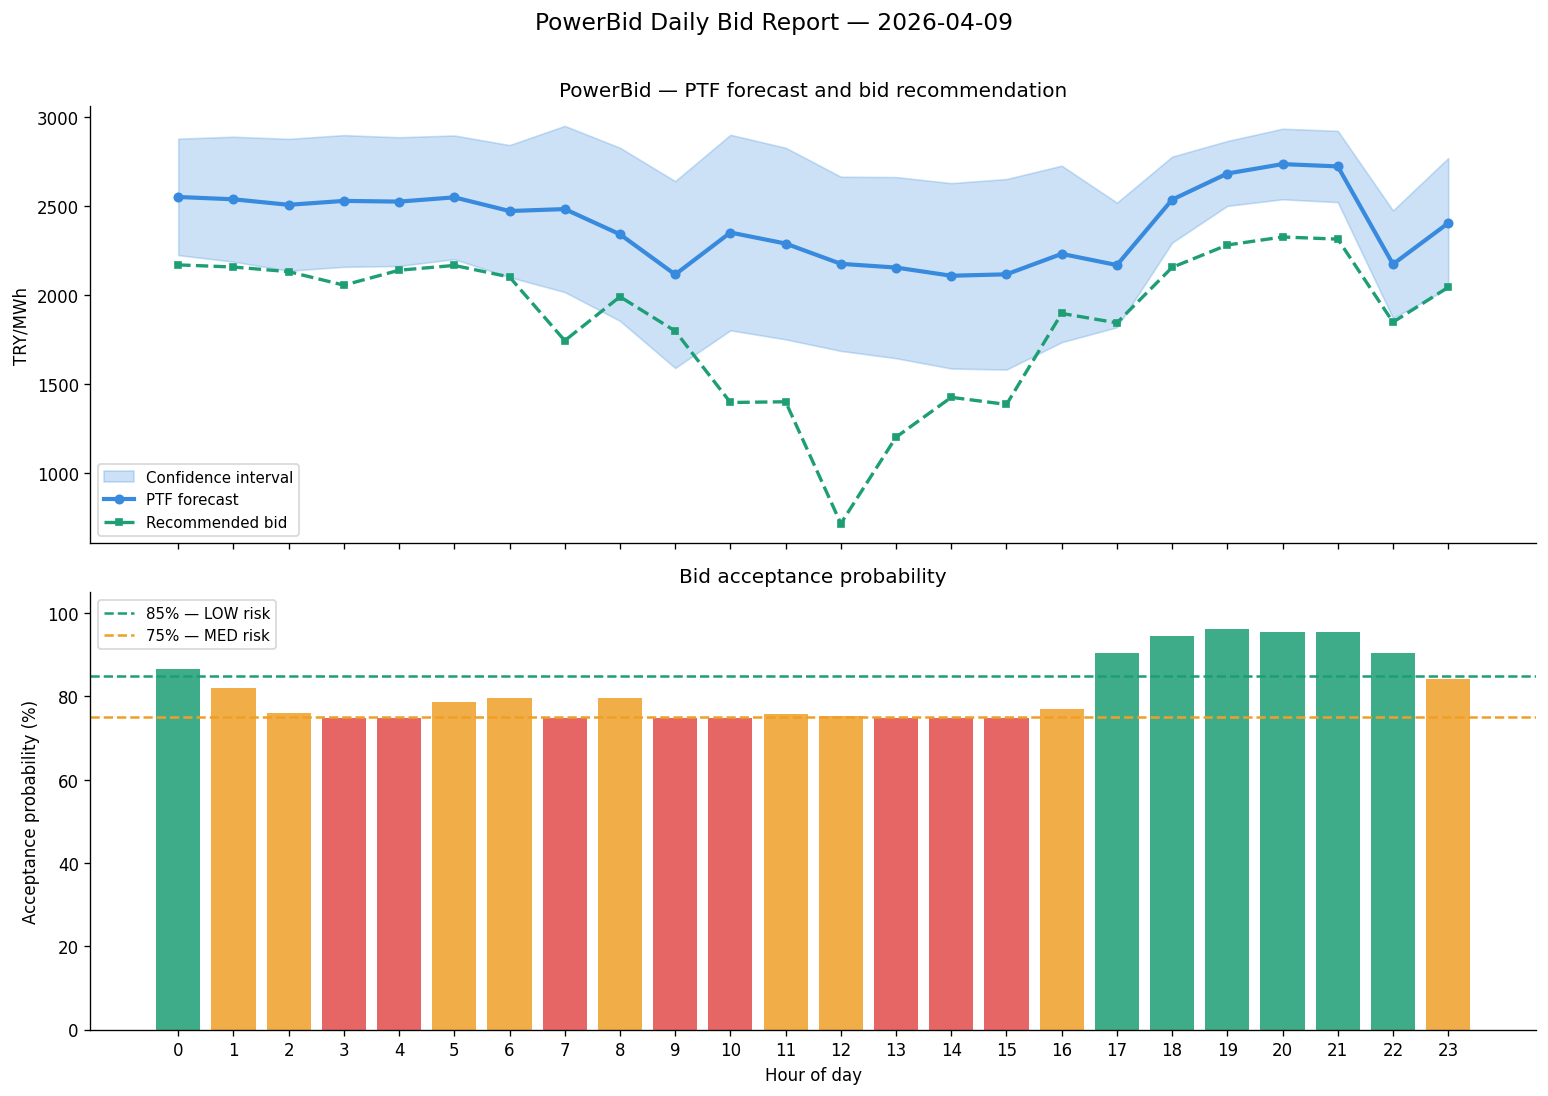

Risk summary : LOW=7h  MED=9h  HIGH=8h
Best hours   : [0, 17, 18, 19, 20, 21, 22]


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
hours = df_report['hour']

axes[0].fill_between(hours,
                     df_report['lower_bound'], df_report['upper_bound'],
                     alpha=0.25, color='#378ADD', label='Confidence interval')
axes[0].plot(hours, df_report['ptf_forecast'],
             color='#378ADD', linewidth=2.5, marker='o', markersize=5,
             label='PTF forecast')
axes[0].plot(hours, df_report['recommended_bid'],
             color='#1D9E75', linewidth=2, marker='s', markersize=4,
             linestyle='--', label='Recommended bid')
axes[0].set_ylabel('TRY/MWh')
axes[0].set_title('PowerBid — PTF forecast and bid recommendation')
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(24))

bar_colors = ['#1D9E75' if p >= 85 else
              '#EF9F27' if p >= 75 else '#E24B4A'
              for p in df_report['acceptance_pct']]
axes[1].bar(hours, df_report['acceptance_pct'], color=bar_colors, alpha=0.85)
axes[1].axhline(85, color='#1D9E75', linewidth=1.5, linestyle='--',
                label='85% — LOW risk')
axes[1].axhline(75, color='#EF9F27', linewidth=1.5, linestyle='--',
                label='75% — MED risk')
axes[1].set_ylabel('Acceptance probability (%)')
axes[1].set_xlabel('Hour of day')
axes[1].set_title('Bid acceptance probability')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(24))
axes[1].set_ylim(0, 105)

plt.suptitle(f'PowerBid Daily Bid Report — {tomorrow}',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

low  = (df_report['risk'] == 'LOW').sum()
med  = (df_report['risk'] == 'MED').sum()
high = (df_report['risk'] == 'HIGH').sum()
print(f'Risk summary : LOW={low}h  MED={med}h  HIGH={high}h')
print(f'Best hours   : {df_report[df_report["risk"]=="LOW"]["hour"].tolist()}')